# Forecasting with the two-strain vaccination ODE model

This notebook reorganizes the workflow into separate steps:

1. Build weekly summaries for Influenza A and Influenza B.
2. Simulate the paper's two-strain vaccination model.
3. Fit the ODE model to weekly-rate data.
4. Plot the fitted curves and save parameters.
5. Generate virtual trajectories by perturbing the fitted ODE parameters.
6. Optionally train a CNN forecaster on the virtual trajectories.

The default fitting code uses the aggregate two-strain model from the paper because the current dataset is weekly aggregate surveillance data. An optional network version is included too; to use it, set `MODEL_VERSION = "network"` and provide a degree distribution `P(k)`.

## Paper model used here

The paper uses two infected states: strain 1 and strain 2. In this notebook:

- `strain1` = Influenza A by default
- `strain2` = Influenza B by default
- `V` = people vaccinated against strain 1
- vaccinated people are still allowed to become infected by strain 2

The ODE is kept in its original state form. The fitted weekly-rate outputs are taken directly from the infected compartments, scaled to the hospitalization-rate units by `rho1` and `rho2`.

In [16]:
# ============================================================
# 0. IMPORTS AND PROJECT SETTINGS
# ============================================================

from __future__ import annotations

from dataclasses import dataclass, asdict, replace
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares


# -----------------------------
# Folders and files
# -----------------------------
ROOT = Path("Influenza_Data")
ROOT.mkdir(parents=True, exist_ok=True)

INPUT_LONG_CSV = ROOT / "weekly_rate_average_median_min_max_by_network_virus.csv"

# Fallback for ChatGPT/Colab-style mounted uploads.
if not INPUT_LONG_CSV.exists() and (Path("/mnt/data") / INPUT_LONG_CSV.name).exists():
    INPUT_LONG_CSV = Path("/mnt/data") / INPUT_LONG_CSV.name

SUMMARY_BY_STRAIN_CSV = ROOT / "weekly_rate_overall_median_AplusB.csv"
SUMMARY_BY_STRAIN_PNG = ROOT / "weekly_rate_overall_median_AplusB.png"

FIT_OUTPUT_CSV = ROOT / "paper_two_strain_fit_weekly_rates.csv"
PARAM_OUTPUT_CSV = ROOT / "paper_two_strain_fit_parameters.csv"
FIT_OUTPUT_PNG = ROOT / "paper_two_strain_fit_weekly_rates.png"
FIT_ONLY_OUTPUT_PNG = ROOT / "paper_two_strain_fitted_trajectory_only.png"

VIRTUAL_OUTPUT_CSV = ROOT / "virtual_paper_two_strain_dataset.csv"
VIRTUAL_BY_STRAIN_OUTPUT_CSV = ROOT / "virtual_paper_two_strain_patients_by_strain.csv"
VIRTUAL_STRAIN1_OUTPUT_CSV = ROOT / "virtual_paper_two_strain_patients_influenza_A.csv"
VIRTUAL_STRAIN2_OUTPUT_CSV = ROOT / "virtual_paper_two_strain_patients_influenza_B.csv"
VIRTUAL_OUTPUT_PNG = ROOT / "virtual_paper_two_strain_examples.png"


# -----------------------------
# Data column settings
# -----------------------------
# Leave these as None to auto-detect common column names.
WEEK_COL = "week"
VALUE_COL = "median_WEEKLY_RATE"
STRAIN_COL = "VIRUS"
STATUS_COL = None

GOOD_STATUS_VALUE = "good_0_29"

STRAIN1_MATCH = "Influenza A"
STRAIN2_MATCH = "Influenza B"
STRAIN1_NAME = "Influenza A"
STRAIN2_NAME = "Influenza B"


# -----------------------------
# ODE model settings
# -----------------------------
# "homogeneous" = paper system (1), good for aggregate weekly rates.
# "network" = paper system (2), requires a degree distribution below.
MODEL_VERSION = "homogeneous"

# Optional degree distribution for the network model.
# If MODEL_VERSION = "network", these define k and P(k).
DEGREES = np.arange(1, 11, dtype=float)
P_K = np.ones_like(DEGREES, dtype=float)
P_K = P_K / P_K.sum()


# -----------------------------
# Fitting settings
# -----------------------------
USE_WEIGHTED_FIT = True
N_RANDOM_STARTS = 100
RANDOM_SEED = 123
MAX_NFEV = 1500

# Fit both strains if the data has separate A/B series.
# If only one total series is available, the notebook will fit total rate = strain1 + strain2.
FIT_TO_TOTAL_ONLY = False

# Fixed biological values.
# Over a 30-week flu season, natural birth/death is often negligible, so defaults are 0.
# You can change r if you want a stronger vaccination flow.
FIXED_VALUES = {
    "gamma1": 7 / 5,   # per week, about 5-day infectious period
    "gamma2": 7 / 5,   # per week
    "r": 0.02,         # vaccination rate into V
    "mu": 0.0,         # natural death/removal rate
    "nu1": 0.0,        # disease-induced death strain 1
    "nu2": 0.0,        # disease-induced death strain 2
    "Lambda": 0.0,     # recruitment into S
    "V0": 0.0,         # initial vaccinated fraction
}

# These parameters are fitted in log-space.
# mu, nu1, nu2, and Lambda stay fixed because they are not identifiable from
# a short 30-week hospitalization-rate curve.
FIT_PARAMETER_NAMES = [
    "beta1",
    "beta2",
    "sigma",
    "gamma1",
    "gamma2",
    "r",
    "I10",
    "I20",
    "V0",
    "rho1",
    "rho2",
]

PARAMETER_BOUNDS = {
    "beta1": (1e-4, 10.0),
    "beta2": (1e-4, 10.0),
    "sigma": (1e-8, 10.0),
    "I10": (1e-10, 0.20),
    "I20": (1e-10, 0.20),
    "rho1": (1e-8, 1e8),
    "rho2": (1e-8, 1e8),
    "gamma1": (0.2, 4.0),
    "gamma2": (0.2, 4.0),
    "r": (1e-8, 1.0),
    "V0": (1e-10, 0.50),
}


In [17]:


# -----------------------------
# Virtual-data settings
# -----------------------------
PERTURB_AMOUNT = 0.80
N_VIRTUAL_PATIENTS_PER_STRAIN = 500
N_VIRTUAL_TRAJECTORIES = N_VIRTUAL_PATIENTS_PER_STRAIN
VIRTUAL_RANDOM_SEED = 42
N_EXAMPLE_VIRTUAL_PLOTS = 5

# Keep generated virtual seasons inside the observed strain and total-rate envelopes.
ENFORCE_OBSERVED_MIN_MAX_BOUNDS = True
MAX_VIRTUAL_GENERATION_ATTEMPTS = 100000000
OBSERVED_BOUND_TOLERANCE = 1e-12

## 1. Load and summarize weekly rates by strain

In [18]:
# ============================================================
# 1. DATA LOADING AND WEEKLY SUMMARY
# ============================================================
# This version is for the pre-summarized file:
# weekly_rate_average_median_min_max_by_network_virus.csv
#
# It creates observed curves for each strain and for total A+B:
#     observed Influenza A median, observed Influenza B median, observed total median
#
# Steps:
#   1. Read median/min/max WEEKLY_RATE for each NETWORK, VIRUS, week.
#   2. Across networks, summarize each VIRUS and week.
#   3. Add Influenza A + Influenza B summaries to get total A+B.
#
# With FIT_TO_TOTAL_ONLY=False, this gives the model strain-specific weekly-rate targets.

def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first matching column, ignoring case and spaces."""
    normalized = {str(c).lower().replace(" ", "").replace("_", ""): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(" ", "").replace("_", "")
        if key in normalized:
            return normalized[key]
    return None


def sigma_from_interval(lower: np.ndarray, upper: np.ndarray) -> np.ndarray:
    """Convert an interval to an approximate standard error for weighted fitting."""
    sigma = (upper - lower) / (2 * 1.96)
    sigma = np.asarray(sigma, dtype=float)

    valid = np.isfinite(sigma) & (sigma > 0)
    if valid.any():
        replacement = float(np.median(sigma[valid]))
    else:
        replacement = 1.0

    sigma[~np.isfinite(sigma)] = replacement
    sigma[sigma <= 0] = replacement
    return sigma


def build_overall_median_AplusB_summary(input_csv: Path) -> pd.DataFrame:
    """
    Build strain-specific median curves and observed min/max envelopes.

    The input file is expected to be:
        weekly_rate_average_median_min_max_by_network_virus.csv

    Required columns:
        NETWORK, VIRUS, week, median_WEEKLY_RATE, min_WEEKLY_RATE, max_WEEKLY_RATE
    """
    df = pd.read_csv(input_csv)

    required = [
        "NETWORK", "VIRUS", "week",
        "median_WEEKLY_RATE", "min_WEEKLY_RATE", "max_WEEKLY_RATE",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing}. Available columns: {list(df.columns)}")

    df = df.copy()
    df["week"] = pd.to_numeric(df["week"], errors="coerce")
    for col in ["median_WEEKLY_RATE", "min_WEEKLY_RATE", "max_WEEKLY_RATE"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=required).copy()
    df["week"] = df["week"].astype(int)

    # Keep only Influenza A and Influenza B.
    df["VIRUS"] = df["VIRUS"].astype(str).str.strip()
    df = df[df["VIRUS"].isin([STRAIN1_NAME, STRAIN2_NAME])].copy()

    if df.empty:
        raise ValueError(
            f"No rows found for {STRAIN1_NAME!r} or {STRAIN2_NAME!r}. "
            f"Unique VIRUS values were: {pd.read_csv(input_csv)['VIRUS'].unique().tolist()}"
        )

    def summarize_strain(virus_name: str, prefix: str) -> pd.DataFrame:
        strain = df[df["VIRUS"] == virus_name].copy()
        if strain.empty:
            return pd.DataFrame(columns=[
                "week", f"median_{prefix}", f"min_observed_{prefix}",
                f"max_observed_{prefix}", f"n_networks_{prefix}",
            ])

        return (
            strain.groupby("week", as_index=False)
            .agg(**{
                f"median_{prefix}": ("median_WEEKLY_RATE", "median"),
                f"min_observed_{prefix}": ("min_WEEKLY_RATE", "min"),
                f"max_observed_{prefix}": ("max_WEEKLY_RATE", "max"),
                f"n_networks_{prefix}": ("NETWORK", "nunique"),
            })
            .sort_values("week")
            .reset_index(drop=True)
        )

    summary = summarize_strain(STRAIN1_NAME, "strain1").merge(
        summarize_strain(STRAIN2_NAME, "strain2"),
        on="week",
        how="outer",
    )
    summary = summary.sort_values("week").reset_index(drop=True)

    rate_cols = [
        "median_strain1", "median_strain2",
        "min_observed_strain1", "min_observed_strain2",
        "max_observed_strain1", "max_observed_strain2",
    ]
    for col in rate_cols:
        summary[col] = pd.to_numeric(summary[col], errors="coerce").fillna(0.0)

    for col in ["n_networks_strain1", "n_networks_strain2"]:
        summary[col] = pd.to_numeric(summary[col], errors="coerce").fillna(0).astype(int)

    summary["median_total"] = summary["median_strain1"] + summary["median_strain2"]
    summary["min_observed_total"] = summary["min_observed_strain1"] + summary["min_observed_strain2"]
    summary["max_observed_total"] = summary["max_observed_strain1"] + summary["max_observed_strain2"]
    summary["n_networks"] = summary[["n_networks_strain1", "n_networks_strain2"]].max(axis=1)

    # Keep the older lower/upper names for the fitting code, but they are min/max bounds.
    summary["lower_95_strain1"] = summary["min_observed_strain1"]
    summary["upper_95_strain1"] = summary["max_observed_strain1"]
    summary["lower_95_strain2"] = summary["min_observed_strain2"]
    summary["upper_95_strain2"] = summary["max_observed_strain2"]
    summary["lower_95_total"] = summary["min_observed_total"]
    summary["upper_95_total"] = summary["max_observed_total"]

    return summary[[
        "week",
        "median_strain1", "min_observed_strain1", "max_observed_strain1",
        "median_strain2", "min_observed_strain2", "max_observed_strain2",
        "median_total", "min_observed_total", "max_observed_total",
        "lower_95_strain1", "upper_95_strain1",
        "lower_95_strain2", "upper_95_strain2",
        "lower_95_total", "upper_95_total",
        "n_networks_strain1", "n_networks_strain2", "n_networks",
    ]]


summary = build_overall_median_AplusB_summary(INPUT_LONG_CSV)
summary.to_csv(SUMMARY_BY_STRAIN_CSV, index=False)

print("Using uploaded precomputed data:")
print(INPUT_LONG_CSV)

print("\nSummary columns:")
print(list(summary.columns))

print("\nSaved:")
print(SUMMARY_BY_STRAIN_CSV)

summary.head()


Using uploaded precomputed data:
Influenza_Data/weekly_rate_average_median_min_max_by_network_virus.csv

Summary columns:
['week', 'median_strain1', 'min_observed_strain1', 'max_observed_strain1', 'median_strain2', 'min_observed_strain2', 'max_observed_strain2', 'median_total', 'min_observed_total', 'max_observed_total', 'lower_95_strain1', 'upper_95_strain1', 'lower_95_strain2', 'upper_95_strain2', 'lower_95_total', 'upper_95_total', 'n_networks_strain1', 'n_networks_strain2', 'n_networks']

Saved:
Influenza_Data/weekly_rate_overall_median_AplusB.csv


,week,median_strain1,min_observed_strain1,max_observed_strain1,median_strain2,min_observed_strain2,max_observed_strain2,median_total,min_observed_total,max_observed_total,lower_95_strain1,upper_95_strain1,lower_95_strain2,upper_95_strain2,lower_95_total,upper_95_total,n_networks_strain1,n_networks_strain2,n_networks
0,0,0.1,0.0,3.6,0.0,0.0,0.1,0.1,0.0,3.7,0.0,3.6,0.0,0.1,0.0,3.7,3,3,3
1,1,0.1,0.0,6.1,0.0,0.0,0.1,0.1,0.0,6.2,0.0,6.1,0.0,0.1,0.0,6.2,3,3,3
2,2,0.1,0.0,5.1,0.0,0.0,0.1,0.1,0.0,5.2,0.0,5.1,0.0,0.1,0.0,5.2,3,3,3
3,3,0.1,0.0,3.5,0.0,0.0,0.1,0.1,0.0,3.6,0.0,3.5,0.0,0.1,0.0,3.6,3,3,3
4,4,0.1,0.0,2.8,0.0,0.0,0.1,0.1,0.0,2.9,0.0,2.8,0.0,0.1,0.0,2.9,3,3,3


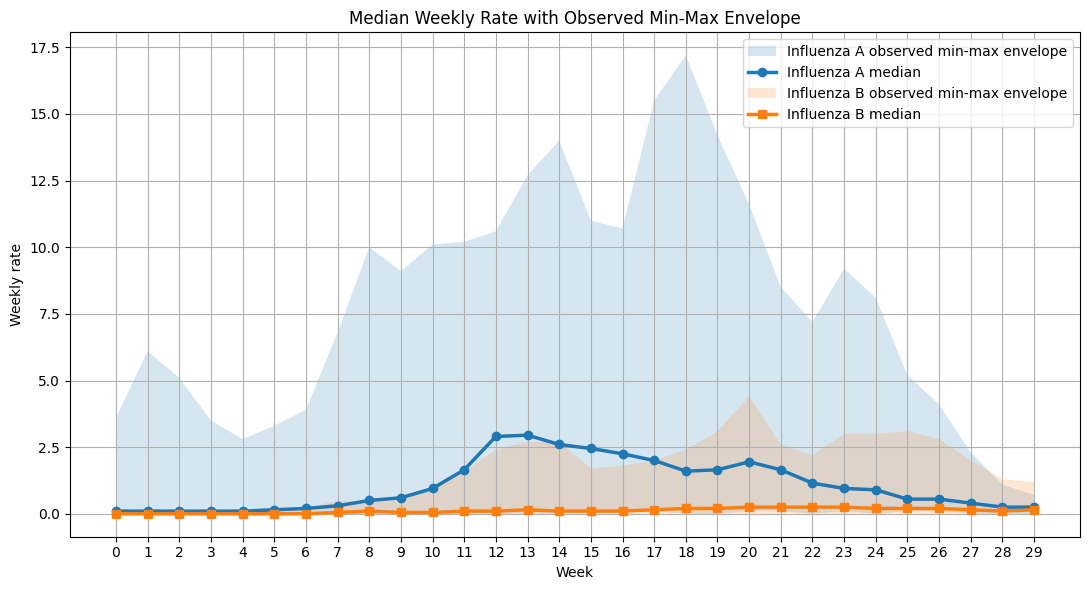

Saved graph:
Influenza_Data/weekly_rate_overall_median_AplusB.png


In [19]:
# ============================================================
# 1B. PLOT WEEKLY SUMMARY
# ============================================================

def plot_weekly_summary(summary: pd.DataFrame, output_png: Path) -> None:
    plt.figure(figsize=(11, 6))

    if {"median_strain1", "median_strain2"}.issubset(summary.columns):
        plt.fill_between(
            summary["week"],
            summary["min_observed_strain1"],
            summary["max_observed_strain1"],
            alpha=0.18,
            label=f"{STRAIN1_NAME} observed min-max envelope",
        )
        plt.plot(
            summary["week"],
            summary["median_strain1"],
            marker="o",
            linewidth=2.5,
            label=f"{STRAIN1_NAME} median",
        )

        plt.fill_between(
            summary["week"],
            summary["min_observed_strain2"],
            summary["max_observed_strain2"],
            alpha=0.18,
            label=f"{STRAIN2_NAME} observed min-max envelope",
        )
        plt.plot(
            summary["week"],
            summary["median_strain2"],
            marker="s",
            linewidth=2.5,
            label=f"{STRAIN2_NAME} median",
        )

    else:
        plt.fill_between(
            summary["week"],
            summary["min_observed_total"],
            summary["max_observed_total"],
            alpha=0.20,
            label="Observed min-max envelope",
        )
        plt.plot(
            summary["week"],
            summary["median_total"],
            marker="o",
            linewidth=2.5,
            label="Total median",
        )

    plt.xlabel("Week")
    plt.ylabel("Weekly rate")
    plt.title("Median Weekly Rate with Observed Min-Max Envelope")
    plt.xticks(range(int(summary["week"].min()), int(summary["week"].max()) + 1))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_png, dpi=300)
    plt.show()

plot_weekly_summary(summary, SUMMARY_BY_STRAIN_PNG)

print("Saved graph:")
print(SUMMARY_BY_STRAIN_PNG)

## 2. Paper two-strain vaccination ODE model

## Homogeneous Two-Strain Vaccination Model

$$
\frac{dS}{dt} = \Lambda - (\beta_1 I_1 + \beta_2 I_2 + \lambda)S
$$

$$
\frac{dV_1}{dt} = rS - (\mu + \sigma I_2)V_1
$$

$$
\frac{dI_1}{dt} = \beta_1 I_1 S - \alpha_1 I_1
$$

$$
\frac{dI_2}{dt} = \beta_2 I_2 S + \sigma I_2 V_1 - \alpha_2 I_2
$$

$$
\frac{dR}{dt} = \gamma_1 I_1 + \gamma_2 I_2 - \mu R
$$

where

$$
\lambda = r + \mu
$$

$$
\alpha_1 = \gamma_1 + \nu_1 + \mu
$$

$$
\alpha_2 = \gamma_2 + \nu_2 + \mu
$$

## Network Two-Strain Vaccination Model

For each degree group $k = 1,2,\dots,n$,

$$
\frac{dS_k}{dt} = \Lambda - \beta_1 k S_k \Theta_1 - \beta_2 k S_k \Theta_2 - \lambda S_k
$$

$$
\frac{dV_k}{dt} = rS_k - \mu V_k - \sigma k V_k \Theta_2
$$

$$
\frac{dI_k}{dt} = \beta_1 k S_k \Theta_1 - \alpha_1 I_k
$$

$$
\frac{dJ_k}{dt} = \beta_2 k S_k \Theta_2 + \sigma k V_k \Theta_2 - \alpha_2 J_k
$$

$$
\frac{dR_k}{dt} = \gamma_1 I_k + \gamma_2 J_k - \mu R_k
$$

where

$$
\lambda = r + \mu
$$

$$
\alpha_1 = \gamma_1 + \nu_1 + \mu
$$

$$
\alpha_2 = \gamma_2 + \nu_2 + \mu
$$

## Network Infection Pressure Terms

$$
\Theta_1(t) =
\frac{\sum_{h=1}^{n} hP(h)I_h(t)}
{\langle k \rangle}
$$

$$
\Theta_2(t) =
\frac{\sum_{h=1}^{n} hP(h)J_h(t)}
{\langle k \rangle}
$$

where

$$
\langle k \rangle = \sum_{h=1}^{n} hP(h)
$$

In [20]:
# ============================================================
# 2. ODE MODEL DEFINITIONS
# ============================================================

@dataclass
class PaperParams:
    beta1: float
    beta2: float
    sigma: float
    gamma1: float
    gamma2: float
    r: float
    mu: float
    nu1: float
    nu2: float
    Lambda: float
    rho1: float
    rho2: float
    I10: float
    I20: float
    V0: float = 0.0


def alpha1(p: PaperParams) -> float:
    return p.gamma1 + p.nu1 + p.mu


def alpha2(p: PaperParams) -> float:
    return p.gamma2 + p.nu2 + p.mu


def paper_homogeneous_rhs(t: float, y: np.ndarray, p: PaperParams) -> list[float]:
    """
    Paper's original aggregate two-strain vaccination model.

    y = [S, V, I1, I2, R]
    """
    S, V, I1, I2, R = y

    # Small numerical protection
    S = max(S, 0.0)
    V = max(V, 0.0)
    I1 = max(I1, 0.0)
    I2 = max(I2, 0.0)

    lam = p.r + p.mu

    new1 = p.beta1 * I1 * S
    new2 = p.beta2 * I2 * S + p.sigma * I2 * V

    dS = p.Lambda - (p.beta1 * I1 + p.beta2 * I2 + lam) * S
    dV = p.r * S - (p.mu + p.sigma * I2) * V
    dI1 = new1 - alpha1(p) * I1
    dI2 = new2 - alpha2(p) * I2
    dR = p.gamma1 * I1 + p.gamma2 * I2 - p.mu * R

    return [dS, dV, dI1, dI2, dR]


def paper_network_rhs(t: float, y: np.ndarray, p: PaperParams, degrees: np.ndarray, pk: np.ndarray) -> np.ndarray:
    """
    Paper's original complex-network model.

    For n degree classes, y stacks:
        S[0:n], V[0:n], I[0:n], J[0:n], R[0:n]
    """
    n = len(degrees)

    S = np.maximum(y[0:n], 0.0)
    V = np.maximum(y[n:2*n], 0.0)
    I = np.maximum(y[2*n:3*n], 0.0)
    J = np.maximum(y[3*n:4*n], 0.0)
    R = y[4*n:5*n]

    mean_k = np.sum(degrees * pk)
    theta1 = np.sum(degrees * pk * I) / mean_k
    theta2 = np.sum(degrees * pk * J) / mean_k

    lam = p.r + p.mu

    new1 = p.beta1 * degrees * S * theta1
    new2 = p.beta2 * degrees * S * theta2 + p.sigma * degrees * V * theta2

    dS = p.Lambda - p.beta1 * degrees * S * theta1 - p.beta2 * degrees * S * theta2 - lam * S
    dV = p.r * S - p.mu * V - p.sigma * degrees * V * theta2
    dI = new1 - alpha1(p) * I
    dJ = new2 - alpha2(p) * J
    dR = p.gamma1 * I + p.gamma2 * J - p.mu * R

    return np.concatenate([dS, dV, dI, dJ, dR])


def make_initial_state(p: PaperParams, model_version: str) -> np.ndarray:
    if p.I10 + p.I20 + p.V0 >= 0.95:
        raise ValueError("Initial fractions are too large: I10 + I20 + V0 must be < 0.95.")

    if model_version == "homogeneous":
        S0 = 1.0 - p.V0 - p.I10 - p.I20
        return np.array([S0, p.V0, p.I10, p.I20, 0.0], dtype=float)

    if model_version == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        n = len(degrees)

        S0 = np.full(n, 1.0 - p.V0 - p.I10 - p.I20, dtype=float)
        V0 = np.full(n, p.V0, dtype=float)
        I0 = np.full(n, p.I10, dtype=float)
        J0 = np.full(n, p.I20, dtype=float)
        R0 = np.zeros(n, dtype=float)

        return np.concatenate([S0, V0, I0, J0, R0])

    raise ValueError("model_version must be 'homogeneous' or 'network'.")


def simulate_paper_model(
    weeks: np.ndarray,
    p: PaperParams,
    model_version: str = MODEL_VERSION,
) -> pd.DataFrame:
    """
    Simulate the original two-strain model and return weekly predicted rates.

    Rates are scaled from the infected-state trajectories. For network simulations,
    infected states are aggregated over degree classes by P(k).
    """
    weeks = np.asarray(weeks, dtype=int)
    max_week = int(np.max(weeks))

    t_eval = np.arange(0, max_week + 1, dtype=float)
    y0 = make_initial_state(p, model_version)

    if model_version == "homogeneous":
        rhs = lambda t, y: paper_homogeneous_rhs(t, y, p)
    elif model_version == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()
        rhs = lambda t, y: paper_network_rhs(t, y, p, degrees, pk)
    else:
        raise ValueError("MODEL_VERSION must be 'homogeneous' or 'network'.")

    sol = solve_ivp(
        fun=rhs,
        t_span=(0.0, float(max_week)),
        y0=y0,
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solver failed: {sol.message}")

    if model_version == "homogeneous":
        strain1_all = np.maximum(sol.y[2, :], 0.0)
        strain2_all = np.maximum(sol.y[3, :], 0.0)

    else:
        n = len(DEGREES)
        I = np.maximum(sol.y[2*n:3*n, :], 0.0)
        J = np.maximum(sol.y[3*n:4*n, :], 0.0)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()

        strain1_all = np.sum(pk[:, None] * I, axis=0)
        strain2_all = np.sum(pk[:, None] * J, axis=0)

    pred1_all = p.rho1 * strain1_all
    pred2_all = p.rho2 * strain2_all

    out = pd.DataFrame({
        "week": weeks,
        "pred_strain1_rate": pred1_all[weeks],
        "pred_strain2_rate": pred2_all[weeks],
    })
    out["pred_total_rate"] = out["pred_strain1_rate"] + out["pred_strain2_rate"]
    return out


def reproduction_numbers(p: PaperParams) -> dict[str, float]:
    """
    Thresholds from the paper.

    For MODEL_VERSION = "homogeneous", <k^2>/<k> is set to 1.
    For MODEL_VERSION = "network", the network factor <k^2>/<k> is used.
    """
    lam = p.r + p.mu

    if lam <= 0:
        return {"R1": np.nan, "R2": np.nan}

    if MODEL_VERSION == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()
        network_factor = np.sum((degrees ** 2) * pk) / np.sum(degrees * pk)
    else:
        network_factor = 1.0

    R1 = (p.beta1 * p.Lambda / (alpha1(p) * lam)) * network_factor

    if p.mu > 0:
        R2 = (p.Lambda * (p.beta2 * p.mu + p.sigma * p.r) / (alpha2(p) * lam * p.mu)) * network_factor
    else:
        R2 = np.nan

    return {"R1": R1, "R2": R2}

## 3. Fit the paper model

In [21]:
# ============================================================
# 3. FITTING HELPERS
# ============================================================

def has_two_strain_data(summary: pd.DataFrame) -> bool:
    return {"median_strain1", "median_strain2"}.issubset(summary.columns)


def build_fit_arrays(summary: pd.DataFrame) -> dict[str, np.ndarray]:
    weeks = summary["week"].to_numpy(dtype=int)

    if has_two_strain_data(summary) and not FIT_TO_TOTAL_ONLY:
        y1 = summary["median_strain1"].to_numpy(dtype=float)
        y2 = summary["median_strain2"].to_numpy(dtype=float)

        s1 = sigma_from_interval(
            summary["lower_95_strain1"].to_numpy(dtype=float),
            summary["upper_95_strain1"].to_numpy(dtype=float),
        )
        s2 = sigma_from_interval(
            summary["lower_95_strain2"].to_numpy(dtype=float),
            summary["upper_95_strain2"].to_numpy(dtype=float),
        )

        return {
            "mode": "two_strain",
            "weeks": weeks,
            "y1": y1,
            "y2": y2,
            "sigma1": s1,
            "sigma2": s2,
        }

    # Total-only fitting.
    if "median_total" in summary.columns:
        y_total = summary["median_total"].to_numpy(dtype=float)
        s_total = sigma_from_interval(
            summary["lower_95_total"].to_numpy(dtype=float),
            summary["upper_95_total"].to_numpy(dtype=float),
        )
    else:
        y_total = (
            summary["median_strain1"].to_numpy(dtype=float)
            + summary["median_strain2"].to_numpy(dtype=float)
        )
        s_total = np.sqrt(
            sigma_from_interval(summary["lower_95_strain1"].to_numpy(dtype=float), summary["upper_95_strain1"].to_numpy(dtype=float)) ** 2
            + sigma_from_interval(summary["lower_95_strain2"].to_numpy(dtype=float), summary["upper_95_strain2"].to_numpy(dtype=float)) ** 2
        )

    return {
        "mode": "total",
        "weeks": weeks,
        "y_total": y_total,
        "sigma_total": s_total,
    }


def make_params_from_theta(theta_log: np.ndarray, names: list[str]) -> PaperParams:
    values = dict(FIXED_VALUES)

    for name, z in zip(names, theta_log):
        values[name] = float(np.exp(z))

    missing = [
        name for name in [
            "beta1", "beta2", "sigma", "gamma1", "gamma2", "r",
            "mu", "nu1", "nu2", "Lambda", "rho1", "rho2", "I10", "I20", "V0"
        ]
        if name not in values
    ]
    if missing:
        raise ValueError(f"Missing parameter values: {missing}")

    return PaperParams(**values)


def theta_bounds(names: list[str]) -> tuple[np.ndarray, np.ndarray]:
    lower = []
    upper = []
    for name in names:
        if name not in PARAMETER_BOUNDS:
            raise ValueError(f"No bounds were provided for fitted parameter {name!r}.")
        lo, hi = PARAMETER_BOUNDS[name]
        if lo <= 0 or hi <= 0:
            raise ValueError("Log-space fitting requires strictly positive bounds.")
        lower.append(np.log(lo))
        upper.append(np.log(hi))

    return np.array(lower, dtype=float), np.array(upper, dtype=float)


def residuals_for_fit(theta_log: np.ndarray, fit_data: dict[str, np.ndarray]) -> np.ndarray:
    try:
        p = make_params_from_theta(theta_log, FIT_PARAMETER_NAMES)

        if p.I10 + p.I20 + p.V0 >= 0.95:
            return np.ones(10, dtype=float) * 1e8

        pred = simulate_paper_model(fit_data["weeks"], p, MODEL_VERSION)

        if fit_data["mode"] == "two_strain":
            r1 = pred["pred_strain1_rate"].to_numpy() - fit_data["y1"]
            r2 = pred["pred_strain2_rate"].to_numpy() - fit_data["y2"]

            if USE_WEIGHTED_FIT:
                r1 = r1 / fit_data["sigma1"]
                r2 = r2 / fit_data["sigma2"]

            return np.concatenate([r1, r2])

        r_total = pred["pred_total_rate"].to_numpy() - fit_data["y_total"]

        if USE_WEIGHTED_FIT:
            r_total = r_total / fit_data["sigma_total"]

        return r_total

    except Exception:
        n = len(fit_data["weeks"])
        if fit_data["mode"] == "two_strain":
            n *= 2
        return np.ones(n, dtype=float) * 1e8


def random_starting_points(names: list[str], n_random: int, seed: int) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    lower, upper = theta_bounds(names)

    starts = []

    # A few manual guesses.
    manual_values = {
        "beta1": [0.8, 1.2, 2.0, 3.0],
        "beta2": [0.8, 1.2, 2.0, 3.0],
        "sigma": [0.05, 0.2, 0.8, 1.5],
        "I10": [1e-6, 1e-5, 1e-4, 1e-3],
        "I20": [1e-6, 1e-5, 1e-4, 1e-3],
        "rho1": [1e2, 1e3, 1e4, 1e5],
        "rho2": [1e2, 1e3, 1e4, 1e5],
        "gamma1": [7 / 5],
        "gamma2": [7 / 5],
        "r": [0.02, 0.05, 0.10],
        "V0": [1e-4, 1e-3, 1e-2],
    }

    for j in range(4):
        vals = []
        for name in names:
            options = manual_values.get(name, [np.exp((lower[names.index(name)] + upper[names.index(name)]) / 2)])
            vals.append(options[min(j, len(options) - 1)])
        starts.append(np.log(np.array(vals, dtype=float)))

    for _ in range(n_random):
        starts.append(rng.uniform(lower, upper))

    # Clip manual starts to bounds.
    starts = [np.clip(s, lower + 1e-12, upper - 1e-12) for s in starts]
    return starts


def fit_paper_model(summary: pd.DataFrame) -> tuple[PaperParams, pd.DataFrame, pd.DataFrame, dict]:
    fit_data = build_fit_arrays(summary)
    lower, upper = theta_bounds(FIT_PARAMETER_NAMES)

    starts = random_starting_points(FIT_PARAMETER_NAMES, N_RANDOM_STARTS, RANDOM_SEED)

    best_result = None
    best_cost = np.inf

    for x0 in starts:
        result = least_squares(
            fun=lambda z: residuals_for_fit(z, fit_data),
            x0=x0,
            bounds=(lower, upper),
            method="trf",
            max_nfev=MAX_NFEV,
        )

        if result.cost < best_cost:
            best_cost = float(result.cost)
            best_result = result

    if best_result is None:
        raise RuntimeError("No optimizer result was produced.")

    best_params = make_params_from_theta(best_result.x, FIT_PARAMETER_NAMES)
    pred = simulate_paper_model(fit_data["weeks"], best_params, MODEL_VERSION)

    fit_df = pd.DataFrame({"week": fit_data["weeks"]})

    if fit_data["mode"] == "two_strain":
        fit_df[f"observed_{STRAIN1_NAME}_rate"] = fit_data["y1"]
        fit_df[f"observed_{STRAIN2_NAME}_rate"] = fit_data["y2"]
        fit_df[f"predicted_{STRAIN1_NAME}_rate"] = pred["pred_strain1_rate"].to_numpy()
        fit_df[f"predicted_{STRAIN2_NAME}_rate"] = pred["pred_strain2_rate"].to_numpy()
        fit_df["observed_total_rate"] = fit_data["y1"] + fit_data["y2"]
        fit_df[f"{STRAIN1_NAME}_residual"] = fit_df[f"predicted_{STRAIN1_NAME}_rate"] - fit_df[f"observed_{STRAIN1_NAME}_rate"]
        fit_df[f"{STRAIN2_NAME}_residual"] = fit_df[f"predicted_{STRAIN2_NAME}_rate"] - fit_df[f"observed_{STRAIN2_NAME}_rate"]
        fit_df[f"{STRAIN1_NAME}_absolute_error"] = np.abs(fit_df[f"{STRAIN1_NAME}_residual"])
        fit_df[f"{STRAIN2_NAME}_absolute_error"] = np.abs(fit_df[f"{STRAIN2_NAME}_residual"])
        fit_df[f"{STRAIN1_NAME}_squared_error"] = fit_df[f"{STRAIN1_NAME}_residual"] ** 2
        fit_df[f"{STRAIN2_NAME}_squared_error"] = fit_df[f"{STRAIN2_NAME}_residual"] ** 2
    else:
        fit_df["observed_total_rate"] = fit_data["y_total"]

    fit_df["predicted_total_rate"] = pred["pred_total_rate"].to_numpy()

    fit_df["total_residual"] = fit_df["predicted_total_rate"] - fit_df["observed_total_rate"]
    fit_df["total_absolute_error"] = np.abs(fit_df["total_residual"])
    fit_df["total_squared_error"] = fit_df["total_residual"] ** 2

    rmse_total = float(np.sqrt(np.mean(fit_df["total_squared_error"])))
    mae_total = float(np.mean(fit_df["total_absolute_error"]))

    rmse_strain1 = np.nan
    mae_strain1 = np.nan
    rmse_strain2 = np.nan
    mae_strain2 = np.nan
    if fit_data["mode"] == "two_strain":
        rmse_strain1 = float(np.sqrt(np.mean(fit_df[f"{STRAIN1_NAME}_squared_error"])))
        mae_strain1 = float(np.mean(fit_df[f"{STRAIN1_NAME}_absolute_error"]))
        rmse_strain2 = float(np.sqrt(np.mean(fit_df[f"{STRAIN2_NAME}_squared_error"])))
        mae_strain2 = float(np.mean(fit_df[f"{STRAIN2_NAME}_absolute_error"]))

    param_rows = []
    for key, value in asdict(best_params).items():
        param_rows.append({"parameter": key, "value": value, "source": "fitted" if key in FIT_PARAMETER_NAMES else "fixed"})

    param_rows.extend([
        {"parameter": f"RMSE_{STRAIN1_NAME}", "value": rmse_strain1, "source": "metric"},
        {"parameter": f"MAE_{STRAIN1_NAME}", "value": mae_strain1, "source": "metric"},
        {"parameter": f"RMSE_{STRAIN2_NAME}", "value": rmse_strain2, "source": "metric"},
        {"parameter": f"MAE_{STRAIN2_NAME}", "value": mae_strain2, "source": "metric"},
        {"parameter": "RMSE_total", "value": rmse_total, "source": "metric"},
        {"parameter": "MAE_total", "value": mae_total, "source": "metric"},
        {"parameter": "weighted_cost", "value": best_result.cost, "source": "metric"},
        {"parameter": "optimizer_success", "value": bool(best_result.success), "source": "metric"},
        {"parameter": "optimizer_message", "value": str(best_result.message), "source": "metric"},
        {"parameter": "MODEL_VERSION", "value": MODEL_VERSION, "source": "setting"},
        {"parameter": "fit_mode", "value": fit_data["mode"], "source": "setting"},
    ])

    for key, value in reproduction_numbers(best_params).items():
        param_rows.append({"parameter": key, "value": value, "source": "threshold"})

    param_df = pd.DataFrame(param_rows)

    metrics = {
        "fit_mode": fit_data["mode"],
        "rmse_strain1": rmse_strain1,
        "mae_strain1": mae_strain1,
        "rmse_strain2": rmse_strain2,
        "mae_strain2": mae_strain2,
        "rmse_total": rmse_total,
        "mae_total": mae_total,
        "weighted_cost": float(best_result.cost),
        "optimizer_success": bool(best_result.success),
        "optimizer_message": str(best_result.message),
    }

    return best_params, fit_df, param_df, metrics

In [22]:
# ============================================================
# 3B. RUN FIT AND SAVE RESULTS
# ============================================================

best_params, fit_df, param_df, fit_metrics = fit_paper_model(summary)

fit_df.to_csv(FIT_OUTPUT_CSV, index=False)
param_df.to_csv(PARAM_OUTPUT_CSV, index=False)

print("\nDONE FITTING PAPER TWO-STRAIN MODEL")
print("-----------------------------------")
print(f"Model version: {MODEL_VERSION}")
print(f"Fit mode: {fit_metrics['fit_mode']}")
print(f"RMSE {STRAIN1_NAME}: {fit_metrics['rmse_strain1']:.6f}")
print(f"RMSE {STRAIN2_NAME}: {fit_metrics['rmse_strain2']:.6f}")
print(f"RMSE total: {fit_metrics['rmse_total']:.6f}")
print(f"MAE {STRAIN1_NAME}:  {fit_metrics['mae_strain1']:.6f}")
print(f"MAE {STRAIN2_NAME}:  {fit_metrics['mae_strain2']:.6f}")
print(f"MAE total:  {fit_metrics['mae_total']:.6f}")
print(f"Cost:       {fit_metrics['weighted_cost']:.6f}")
print(f"Success:    {fit_metrics['optimizer_success']}")

print("\nFitted/fixed parameters:")
display(param_df)

print("\nSaved fitted values:")
print(FIT_OUTPUT_CSV)

print("\nSaved parameters:")
print(PARAM_OUTPUT_CSV)


DONE FITTING PAPER TWO-STRAIN MODEL
-----------------------------------
Model version: homogeneous
Fit mode: two_strain
RMSE Influenza A: 0.244105
RMSE Influenza B: 0.039726
RMSE total: 0.262230
MAE Influenza A:  0.183851
MAE Influenza B:  0.029860
MAE total:  0.205930
Cost:       0.489683
Success:    True

Fitted/fixed parameters:


,parameter,value,source
0,beta1,4.295591,fitted
1,beta2,2.403353,fitted
2,sigma,0.148516,fitted
3,gamma1,0.242974,fitted
4,gamma2,0.200001,fitted
5,r,0.195833,fitted
6,mu,0.0,fixed
7,nu1,0.0,fixed
8,nu2,0.0,fixed
9,Lambda,0.0,fixed



Saved fitted values:
Influenza_Data/paper_two_strain_fit_weekly_rates.csv

Saved parameters:
Influenza_Data/paper_two_strain_fit_parameters.csv


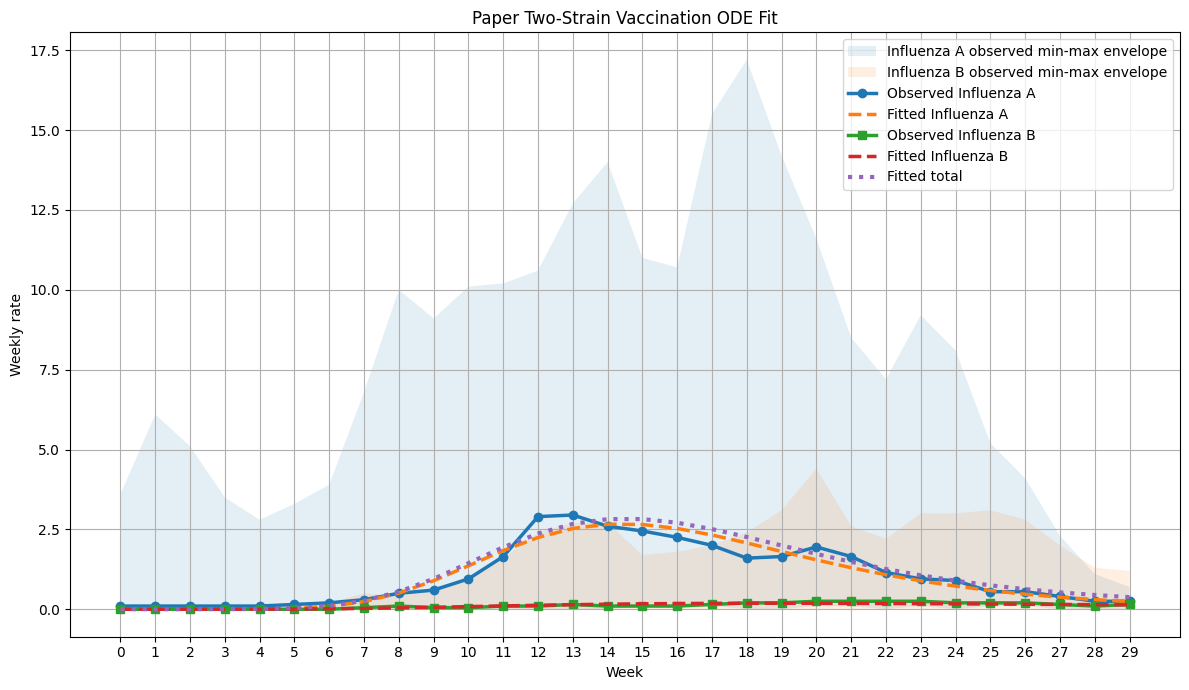

Saved graph:
Influenza_Data/paper_two_strain_fit_weekly_rates.png


In [23]:
# ============================================================
# 3C. PLOT FIT
# ============================================================

plt.figure(figsize=(12, 7))

if f"observed_{STRAIN1_NAME}_rate" in fit_df.columns:
    plt.fill_between(
        summary["week"],
        summary["min_observed_strain1"],
        summary["max_observed_strain1"],
        alpha=0.12,
        label=f"{STRAIN1_NAME} observed min-max envelope",
    )
    plt.fill_between(
        summary["week"],
        summary["min_observed_strain2"],
        summary["max_observed_strain2"],
        alpha=0.12,
        label=f"{STRAIN2_NAME} observed min-max envelope",
    )

    plt.plot(
        fit_df["week"],
        fit_df[f"observed_{STRAIN1_NAME}_rate"],
        marker="o",
        linewidth=2.5,
        label=f"Observed {STRAIN1_NAME}",
    )
    plt.plot(
        fit_df["week"],
        fit_df[f"predicted_{STRAIN1_NAME}_rate"],
        linestyle="--",
        linewidth=2.5,
        label=f"Fitted {STRAIN1_NAME}",
    )

    plt.plot(
        fit_df["week"],
        fit_df[f"observed_{STRAIN2_NAME}_rate"],
        marker="s",
        linewidth=2.5,
        label=f"Observed {STRAIN2_NAME}",
    )
    plt.plot(
        fit_df["week"],
        fit_df[f"predicted_{STRAIN2_NAME}_rate"],
        linestyle="--",
        linewidth=2.5,
        label=f"Fitted {STRAIN2_NAME}",
    )

else:
    plt.fill_between(
        summary["week"],
        summary["min_observed_total"],
        summary["max_observed_total"],
        alpha=0.16,
        label="Observed total min-max envelope",
    )

    plt.plot(
        fit_df["week"],
        fit_df["observed_total_rate"],
        marker="o",
        linewidth=2.5,
        label="Observed total",
    )

plt.plot(
    fit_df["week"],
    fit_df["predicted_total_rate"],
    linestyle=":",
    linewidth=3.0,
    label="Fitted total",
)

plt.xlabel("Week")
plt.ylabel("Weekly rate")
plt.title("Paper Two-Strain Vaccination ODE Fit")
plt.xticks(range(int(fit_df["week"].min()), int(fit_df["week"].max()) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIT_OUTPUT_PNG, dpi=300)
plt.show()

print("Saved graph:")
print(FIT_OUTPUT_PNG)

## 4. Generate virtual trajectories from the fitted ODE model

In [11]:
# ============================================================
# 4. VIRTUAL DATASET FROM PERTURBED PAPER MODEL
# ============================================================

def perturb_params(
    p: PaperParams,
    amount: float,
    rng: np.random.Generator,
    names_to_perturb: list[str] | None = None,
) -> PaperParams:
    """
    Perturb selected positive parameters by multiplying by (1 + uniform(-amount, amount)).
    """
    if names_to_perturb is None:
        names_to_perturb = list(FIT_PARAMETER_NAMES)

    values = asdict(p)

    for name in names_to_perturb:
        factor = 1.0 + rng.uniform(-amount, amount)
        values[name] = max(float(values[name]) * factor, 1e-12)

    if values["I10"] + values["I20"] + values["V0"] >= 0.95:
        scale = 0.90 / (values["I10"] + values["I20"] + values["V0"])
        values["I10"] *= scale
        values["I20"] *= scale
        values["V0"] *= scale

    return PaperParams(**values)


def trajectory_stays_within_observed_bounds(
    pred: pd.DataFrame,
    observed_bounds: pd.DataFrame,
    tolerance: float = OBSERVED_BOUND_TOLERANCE,
) -> bool:
    """Return True only when each strain stays inside its own observed min/max band."""
    checks = [
        ("pred_strain1_rate", "min_observed_strain1", "max_observed_strain1"),
        ("pred_strain2_rate", "min_observed_strain2", "max_observed_strain2"),
    ]

    pred_cols = [pred_col for pred_col, _, _ in checks]
    bound_cols = ["week"] + [col for _, lower_col, upper_col in checks for col in [lower_col, upper_col]]
    missing_pred = [col for col in pred_cols if col not in pred.columns]
    missing_bounds = [col for col in bound_cols if col not in observed_bounds.columns]
    if missing_pred:
        raise ValueError(f"Missing prediction columns: {missing_pred}")
    if missing_bounds:
        raise ValueError(f"Missing observed-bound columns: {missing_bounds}")

    check = pred[["week"] + pred_cols].merge(
        observed_bounds[bound_cols],
        on="week",
        how="left",
        validate="one_to_one",
    )

    missing_week_bounds = check[bound_cols[1:]].isna().any(axis=1)
    if missing_week_bounds.any():
        missing_weeks = check.loc[missing_week_bounds, "week"].tolist()
        raise ValueError(f"No observed min/max bounds for weeks: {missing_weeks}")

    inside = np.ones(len(check), dtype=bool)
    for pred_col, lower_col, upper_col in checks:
        inside &= (
            (check[pred_col] >= check[lower_col] - tolerance)
            & (check[pred_col] <= check[upper_col] + tolerance)
        )

    return bool(inside.all())


def create_virtual_dataset(
    p: PaperParams,
    weeks: np.ndarray,
    n_trajectories: int,
    perturb_amount: float,
    seed: int,
    observed_bounds: pd.DataFrame | None = None,
    enforce_bounds: bool = ENFORCE_OBSERVED_MIN_MAX_BOUNDS,
    max_attempts: int = MAX_VIRTUAL_GENERATION_ATTEMPTS,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    accepted = 0
    attempts = 0
    rejected = 0

    if enforce_bounds and observed_bounds is None:
        raise ValueError("observed_bounds is required when enforce_bounds=True.")

    while accepted < n_trajectories and attempts < max_attempts:
        attempts += 1
        p_virtual = perturb_params(p, perturb_amount, rng)
        pred = simulate_paper_model(weeks, p_virtual, MODEL_VERSION)

        if enforce_bounds and not trajectory_stays_within_observed_bounds(pred, observed_bounds):
            rejected += 1
            continue

        accepted += 1
        virtual_id = accepted

        for _, row in pred.iterrows():
            rows.append({
                "virtual_id": virtual_id,
                "generation_attempt": attempts,
                "week": int(row["week"]),
                "virtual_strain1_rate": float(row["pred_strain1_rate"]),
                "virtual_strain2_rate": float(row["pred_strain2_rate"]),
                "virtual_total_rate": float(row["pred_total_rate"]),
                "beta1": p_virtual.beta1,
                "beta2": p_virtual.beta2,
                "sigma": p_virtual.sigma,
                "gamma1": p_virtual.gamma1,
                "gamma2": p_virtual.gamma2,
                "r": p_virtual.r,
                "mu": p_virtual.mu,
                "nu1": p_virtual.nu1,
                "nu2": p_virtual.nu2,
                "Lambda": p_virtual.Lambda,
                "rho1": p_virtual.rho1,
                "rho2": p_virtual.rho2,
                "I10": p_virtual.I10,
                "I20": p_virtual.I20,
                "V0": p_virtual.V0,
            })

    if accepted < n_trajectories:
        raise RuntimeError(
            f"Accepted only {accepted} of {n_trajectories} requested trajectories after "
            f"{attempts} attempts. Try lowering PERTURB_AMOUNT or increasing "
            "MAX_VIRTUAL_GENERATION_ATTEMPTS."
        )

    virtual_df = pd.DataFrame(rows)
    virtual_df.attrs["generation_attempts"] = attempts
    virtual_df.attrs["rejected_trajectories"] = rejected
    return virtual_df


def make_virtual_patients_by_strain(
    virtual_df: pd.DataFrame,
    summary: pd.DataFrame,
) -> pd.DataFrame:
    """Convert joint two-strain virtual trajectories into 500 patients per strain."""
    parameter_cols = [
        "beta1", "beta2", "sigma", "gamma1", "gamma2", "r", "mu",
        "nu1", "nu2", "Lambda", "rho1", "rho2", "I10", "I20", "V0",
    ]

    strain_specs = [
        {
            "strain": STRAIN1_NAME,
            "strain_id": "A",
            "rate_col": "virtual_strain1_rate",
            "median_col": "median_strain1",
            "min_col": "min_observed_strain1",
            "max_col": "max_observed_strain1",
        },
        {
            "strain": STRAIN2_NAME,
            "strain_id": "B",
            "rate_col": "virtual_strain2_rate",
            "median_col": "median_strain2",
            "min_col": "min_observed_strain2",
            "max_col": "max_observed_strain2",
        },
    ]

    bound_lookup = summary[[
        "week",
        "median_strain1", "min_observed_strain1", "max_observed_strain1",
        "median_strain2", "min_observed_strain2", "max_observed_strain2",
    ]].copy()

    patient_frames = []
    for spec in strain_specs:
        cols = ["virtual_id", "generation_attempt", "week", spec["rate_col"]] + parameter_cols
        temp = virtual_df[cols].copy()
        temp = temp.rename(columns={spec["rate_col"]: "virtual_WEEKLY_RATE"})
        temp["strain"] = spec["strain"]
        temp["strain_id"] = spec["strain_id"]
        temp["virtual_patient_id"] = temp["strain_id"] + "_" + temp["virtual_id"].astype(str).str.zfill(4)

        temp = temp.merge(bound_lookup, on="week", how="left", validate="many_to_one")
        temp["observed_median"] = temp[spec["median_col"]]
        temp["observed_min_bound"] = temp[spec["min_col"]]
        temp["observed_max_bound"] = temp[spec["max_col"]]
        temp["within_strain_bound"] = temp["virtual_WEEKLY_RATE"].between(
            temp["observed_min_bound"] - OBSERVED_BOUND_TOLERANCE,
            temp["observed_max_bound"] + OBSERVED_BOUND_TOLERANCE,
        )

        drop_cols = [
            "median_strain1", "min_observed_strain1", "max_observed_strain1",
            "median_strain2", "min_observed_strain2", "max_observed_strain2",
        ]
        temp = temp.drop(columns=drop_cols)
        patient_frames.append(temp)

    patients = pd.concat(patient_frames, ignore_index=True)
    patients = patients.sort_values(["strain", "virtual_id", "week"]).reset_index(drop=True)

    if not patients["within_strain_bound"].all():
        bad = patients.loc[~patients["within_strain_bound"], ["strain", "virtual_patient_id", "week"]]
        raise RuntimeError(f"Generated patients outside strain bounds:\n{bad.head()}")

    return patients


weeks = fit_df["week"].to_numpy(dtype=int)
observed_bounds = summary[[
    "week",
    "min_observed_strain1", "max_observed_strain1",
    "min_observed_strain2", "max_observed_strain2",
    "min_observed_total", "max_observed_total",
]].copy()

virtual_df = create_virtual_dataset(
    p=best_params,
    weeks=weeks,
    n_trajectories=N_VIRTUAL_TRAJECTORIES,
    perturb_amount=PERTURB_AMOUNT,
    seed=VIRTUAL_RANDOM_SEED,
    observed_bounds=observed_bounds,
    enforce_bounds=ENFORCE_OBSERVED_MIN_MAX_BOUNDS,
    max_attempts=MAX_VIRTUAL_GENERATION_ATTEMPTS,
)

virtual_df.to_csv(VIRTUAL_OUTPUT_CSV, index=False)

virtual_patients_by_strain_df = make_virtual_patients_by_strain(virtual_df, summary)
virtual_patients_by_strain_df.to_csv(VIRTUAL_BY_STRAIN_OUTPUT_CSV, index=False)

virtual_patients_by_strain_df[
    virtual_patients_by_strain_df["strain"] == STRAIN1_NAME
].to_csv(VIRTUAL_STRAIN1_OUTPUT_CSV, index=False)

virtual_patients_by_strain_df[
    virtual_patients_by_strain_df["strain"] == STRAIN2_NAME
].to_csv(VIRTUAL_STRAIN2_OUTPUT_CSV, index=False)

print("Virtual dataset shape:")
print(virtual_df.shape)

print("\nVirtual patients per strain:")
print(virtual_patients_by_strain_df.groupby("strain")["virtual_patient_id"].nunique())

print("\nGeneration attempts:")
print(virtual_df.attrs.get("generation_attempts"))

print("\nRejected trajectories:")
print(virtual_df.attrs.get("rejected_trajectories"))

print("\nSaved:")
print(VIRTUAL_OUTPUT_CSV)
print(VIRTUAL_BY_STRAIN_OUTPUT_CSV)
print(VIRTUAL_STRAIN1_OUTPUT_CSV)
print(VIRTUAL_STRAIN2_OUTPUT_CSV)

virtual_patients_by_strain_df.head()

Virtual dataset shape:
(15000, 21)

Virtual patients per strain:
strain
Influenza A    500
Influenza B    500
Name: virtual_patient_id, dtype: int64

Generation attempts:
18674

Rejected trajectories:
18174

Saved:
Influenza_Data/virtual_paper_two_strain_dataset.csv
Influenza_Data/virtual_paper_two_strain_patients_by_strain.csv
Influenza_Data/virtual_paper_two_strain_patients_influenza_A.csv
Influenza_Data/virtual_paper_two_strain_patients_influenza_B.csv


,virtual_id,generation_attempt,week,virtual_WEEKLY_RATE,beta1,beta2,sigma,gamma1,gamma2,r,...,I10,I20,V0,strain,strain_id,virtual_patient_id,observed_median,observed_min_bound,observed_max_bound,within_strain_bound
0,1,31,0,0.000162,3.307933,0.996789,0.229097,0.315433,0.105152,0.151438,...,1.038825e-10,3.862782e-10,0.00004,Influenza A,A,A_0001,0.1,0.0,3.6,True
1,1,31,1,0.001655,3.307933,0.996789,0.229097,0.315433,0.105152,0.151438,...,1.038825e-10,3.862782e-10,0.00004,Influenza A,A,A_0001,0.1,0.0,6.1,True
2,1,31,2,0.011029,3.307933,0.996789,0.229097,0.315433,0.105152,0.151438,...,1.038825e-10,3.862782e-10,0.00004,Influenza A,A,A_0001,0.1,0.0,5.1,True
3,1,31,3,0.052937,3.307933,0.996789,0.229097,0.315433,0.105152,0.151438,...,1.038825e-10,3.862782e-10,0.00004,Influenza A,A,A_0001,0.1,0.0,3.5,True
4,1,31,4,0.195367,3.307933,0.996789,0.229097,0.315433,0.105152,0.151438,...,1.038825e-10,3.862782e-10,0.00004,Influenza A,A,A_0001,0.1,0.0,2.8,True


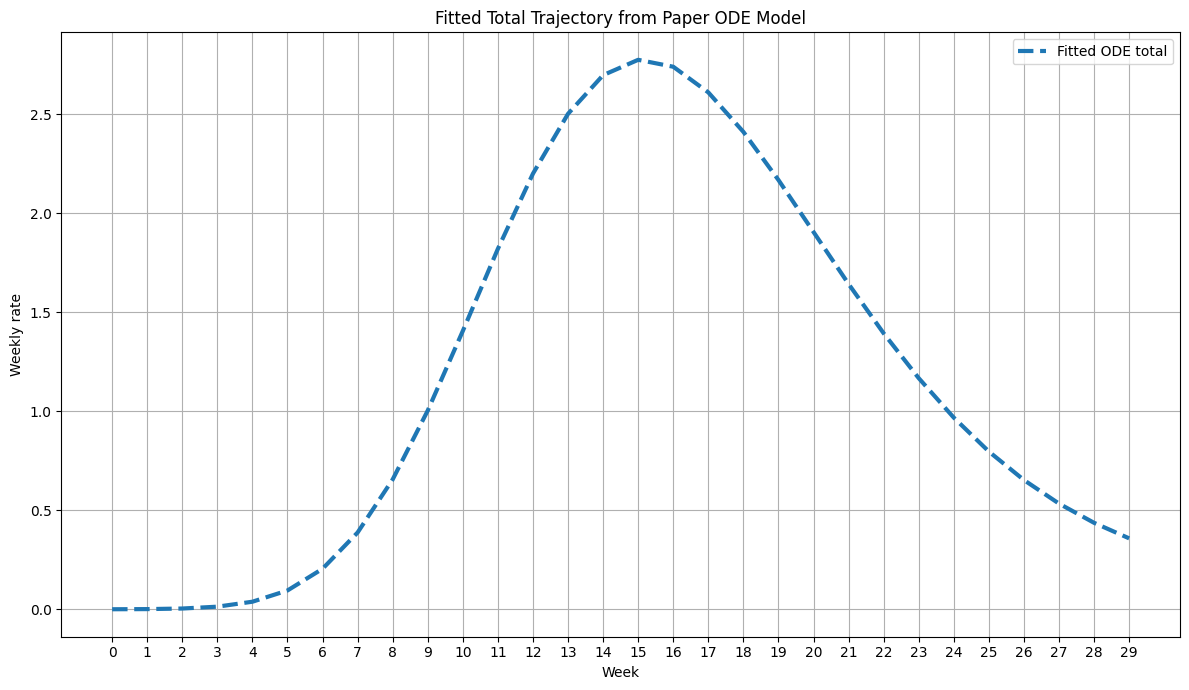

Saved graph:
Influenza_Data/paper_two_strain_fitted_trajectory_only.png


In [12]:
# ============================================================
# 4B. PLOT FITTED TRAJECTORY ONLY
# ============================================================

plt.figure(figsize=(12, 7))

plt.plot(
    fit_df["week"],
    fit_df["predicted_total_rate"],
    linestyle="--",
    linewidth=3,
    label="Fitted ODE total",
)

plt.xlabel("Week")
plt.ylabel("Weekly rate")
plt.title("Fitted Total Trajectory from Paper ODE Model")
plt.xticks(range(int(fit_df["week"].min()), int(fit_df["week"].max()) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIT_ONLY_OUTPUT_PNG, dpi=300)
plt.show()

print("Saved graph:")
print(FIT_ONLY_OUTPUT_PNG)

## 5. Optional CNN forecaster trained on virtual ODE trajectories

In [13]:
# ============================================================
# 5. OPTIONAL CNN FORECAST MODEL
# ============================================================
# Run this cell only after creating the virtual dataset.
# The default target is total weekly rate. You can change TARGET_COL
# to "virtual_strain1_rate" or "virtual_strain2_rate".

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

TARGET_COL = "virtual_total_rate"
GIVEN_VALUES = 15
EPOCHS = 300
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
USE_EARLY_STOPPING = True

CNN_MODEL_PATH = ROOT / f"cnn_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}.keras"
CNN_METADATA_PATH = ROOT / f"cnn_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}_metadata.json"
CNN_PREDICTIONS_CSV = ROOT / f"cnn_paper_ode_predictions_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
CNN_PLOT_PATH = ROOT / f"cnn_paper_ode_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.png"


def make_supervised_dataset_from_virtual(
    virtual_df: pd.DataFrame,
    target_col: str,
    given_values: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    wide = (
        virtual_df.pivot(index="virtual_id", columns="week", values=target_col)
        .sort_index(axis=1)
        .dropna()
    )

    values = wide.to_numpy(dtype=float)
    weeks_arr = wide.columns.to_numpy(dtype=int)

    if given_values >= values.shape[1]:
        raise ValueError("GIVEN_VALUES must be smaller than the total number of weeks.")

    X = values[:, :given_values]
    y = values[:, given_values:]

    return X, y, weeks_arr


X_raw, y_raw, cnn_weeks = make_supervised_dataset_from_virtual(
    virtual_df=virtual_df,
    target_col=TARGET_COL,
    given_values=GIVEN_VALUES,
)

train_mean = float(X_raw.mean())
train_std = float(X_raw.std())

if train_std <= 0:
    train_std = 1.0

X = (X_raw - train_mean) / train_std
y = (y_raw - train_mean) / train_std

X = X[..., None]

n_samples = X.shape[0]
rng = np.random.default_rng(123)
idx = rng.permutation(n_samples)

split = int(0.80 * n_samples)
train_idx = idx[:split]
val_idx = idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

forecast_horizon = y.shape[1]

model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", padding="causal", input_shape=(GIVEN_VALUES, 1)),
    BatchNormalization(),
    Dropout(0.15),

    Conv1D(64, kernel_size=3, activation="relu", padding="causal"),
    BatchNormalization(),
    Dropout(0.15),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.10),
    Dense(forecast_horizon),
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

callbacks = []
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStopping(
            monitor="val_loss",
            patience=40,
            restore_best_weights=True,
        )
    )

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

model.save(CNN_MODEL_PATH)

metadata = {
    "TARGET_COL": TARGET_COL,
    "GIVEN_VALUES": GIVEN_VALUES,
    "TOTAL_WEEKS": int(len(cnn_weeks)),
    "FORECAST_HORIZON": int(forecast_horizon),
    "weeks": cnn_weeks.tolist(),
    "train_mean": train_mean,
    "train_std": train_std,
}

with open(CNN_METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved CNN model:")
print(CNN_MODEL_PATH)

print("\nSaved metadata:")
print(CNN_METADATA_PATH)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-09 13:03:42.755023: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-09 13:03:42.755189: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-09 13:03:42.755446: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1781028222.756122 12379004 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781028222.756981 12379004 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replic

Epoch 1/300


2026-06-09 13:03:44.160830: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.7508 - mae: 0.6429 - val_loss: 0.4552 - val_mae: 0.4933
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2397 - mae: 0.3839 - val_loss: 0.4132 - val_mae: 0.4696
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2088 - mae: 0.3568 - val_loss: 0.3679 - val_mae: 0.4430
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1826 - mae: 0.3270 - val_loss: 0.3481 - val_mae: 0.4310
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1488 - mae: 0.3037 - val_loss: 0.3106 - val_mae: 0.4094
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1565 - mae: 0.3070 - val_loss: 0.3129 - val_mae: 0.4030
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1212 - mae: 0.2621 - val_loss: 0.2739 - val_mae: 0.3710
Epoch 8/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1085 - mae: 0.2418 - val_loss: 0.2575 - val_mae: 0.3636
Epoch 9/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1014 -

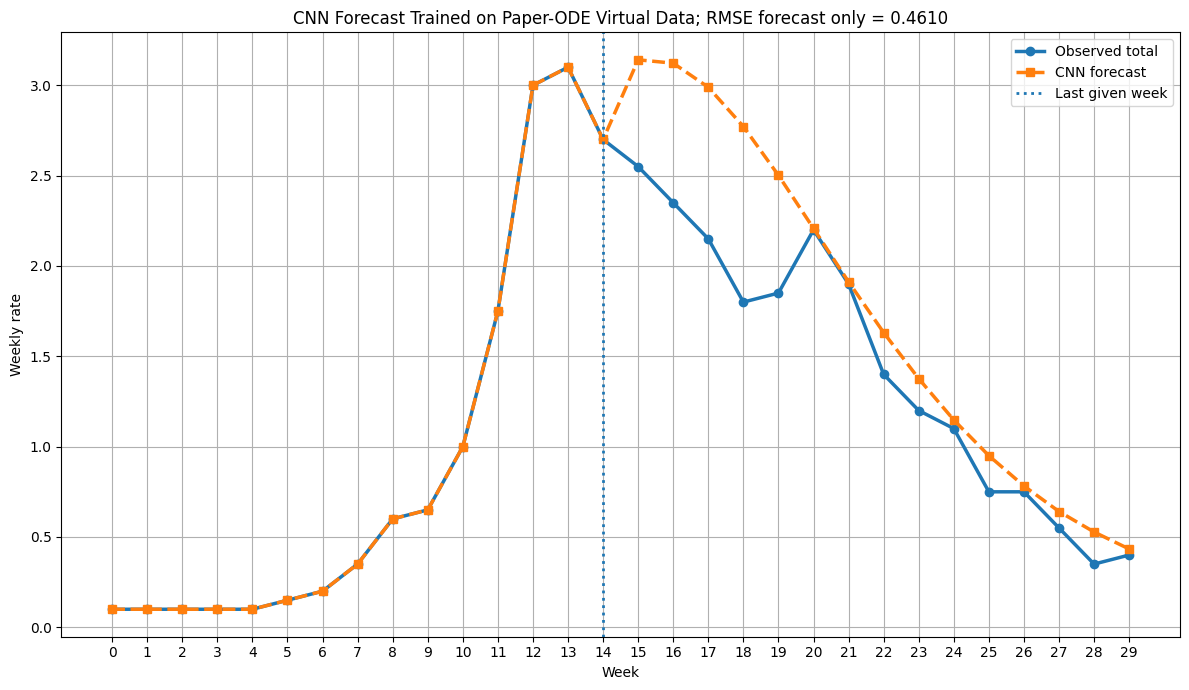

Forecast-only RMSE:
0.46097405733390706

Saved forecast CSV:
Influenza_Data/cnn_paper_ode_predictions_virtual_total_rate_given_15.csv

Saved forecast graph:
Influenza_Data/cnn_paper_ode_forecast_virtual_total_rate_given_15.png


In [14]:
# ============================================================
# 5B. TEST CNN ON THE FITTED OBSERVED TOTAL CURVE
# ============================================================

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model(CNN_MODEL_PATH)

with open(CNN_METADATA_PATH, "r") as f:
    metadata = json.load(f)

given_values = metadata["GIVEN_VALUES"]
train_mean = metadata["train_mean"]
train_std = metadata["train_std"]
cnn_weeks = np.array(metadata["weeks"], dtype=int)

observed_total = fit_df["observed_total_rate"].to_numpy(dtype=float)
given = observed_total[:given_values]

X_user = ((given - train_mean) / train_std).reshape(1, given_values, 1)

pred_scaled = model.predict(X_user, verbose=0)[0]
pred_future = pred_scaled * train_std + train_mean

forecast_weeks = cnn_weeks[given_values:]

forecast_df = pd.DataFrame({
    "week": cnn_weeks,
    "observed_total_rate": observed_total,
    "cnn_prediction": np.concatenate([given, pred_future]),
    "is_given_to_model": [True] * given_values + [False] * len(pred_future),
})

forecast_df["error"] = forecast_df["cnn_prediction"] - forecast_df["observed_total_rate"]
forecast_df["absolute_error"] = np.abs(forecast_df["error"])
forecast_df["squared_error"] = forecast_df["error"] ** 2

rmse_forecast_only = np.sqrt(
    forecast_df.loc[~forecast_df["is_given_to_model"], "squared_error"].mean()
)

forecast_df.to_csv(CNN_PREDICTIONS_CSV, index=False)

plt.figure(figsize=(12, 7))
plt.plot(
    forecast_df["week"],
    forecast_df["observed_total_rate"],
    marker="o",
    linewidth=2.5,
    label="Observed total",
)
plt.plot(
    forecast_df["week"],
    forecast_df["cnn_prediction"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label="CNN forecast",
)
plt.axvline(
    x=int(cnn_weeks[given_values - 1]),
    linestyle=":",
    linewidth=2,
    label="Last given week",
)
plt.xlabel("Week")
plt.ylabel("Weekly rate")
plt.title(f"CNN Forecast Trained on Paper-ODE Virtual Data; RMSE forecast only = {rmse_forecast_only:.4f}")
plt.xticks(range(int(cnn_weeks.min()), int(cnn_weeks.max()) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(CNN_PLOT_PATH, dpi=300)
plt.show()

print("Forecast-only RMSE:")
print(rmse_forecast_only)

print("\nSaved forecast CSV:")
print(CNN_PREDICTIONS_CSV)

print("\nSaved forecast graph:")
print(CNN_PLOT_PATH)

CNN forecast-horizon test results:


,csv_path,value_col,given_values,last_given_week,forecast_step,forecast_week,model_forecast_week,forecasted_value,actual_value,error,absolute_error,squared_error,rmse,overall_rmse
0,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,1,15,15,0.211057,0.1,0.111057,0.111057,0.012334,0.074305,0.074305
1,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,2,16,16,0.218848,0.1,0.118848,0.118848,0.014125,0.074305,0.074305
2,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,3,17,17,0.228648,0.2,0.028648,0.028648,0.000821,0.074305,0.074305
3,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,4,18,18,0.224885,0.2,0.024885,0.024885,0.000619,0.074305,0.074305
4,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,5,19,19,0.230244,0.2,0.030244,0.030244,0.000915,0.074305,0.074305
5,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,6,20,20,0.231003,0.3,-0.068997,0.068997,0.004761,0.074305,0.074305
6,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,7,21,21,0.230811,0.2,0.030811,0.030811,0.000949,0.074305,0.074305
7,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,8,22,22,0.221030,0.2,0.021030,0.021030,0.000442,0.074305,0.074305
8,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,9,23,23,0.218037,0.2,0.018037,0.018037,0.000325,0.074305,0.074305
9,EIP_2010-11_Influenza_B.csv,WEEKLY RATE,15,14,10,24,24,0.209963,0.1,0.109963,0.109963,0.012092,0.074305,0.074305


Overall forecast-horizon RMSE:
0.07430471804914533


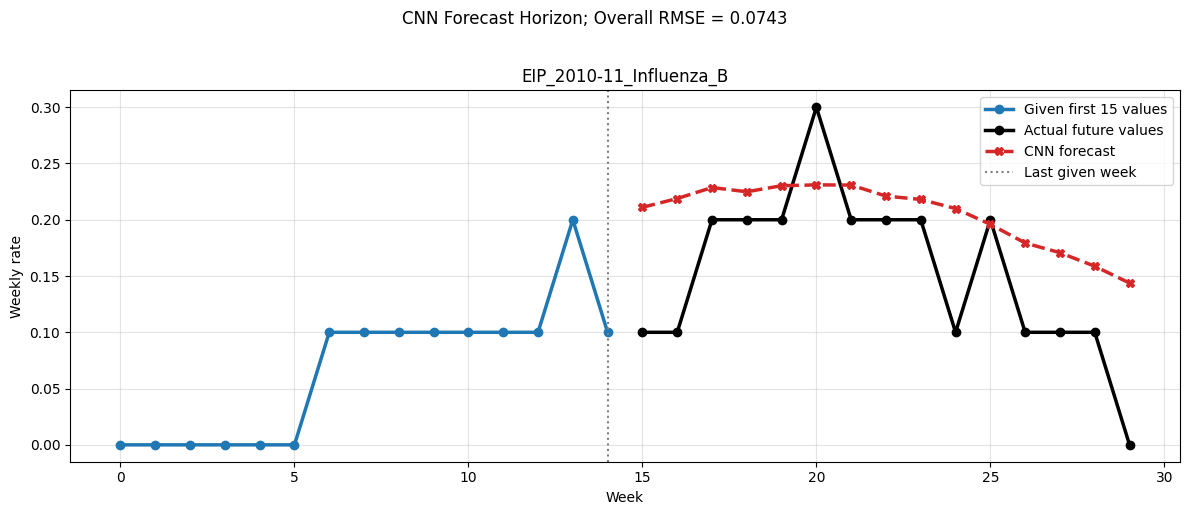


Saved forecast-horizon test CSV:
Influenza_Data/cnn_forecast_horizon_csv_test_results.csv

Saved CNN forecast plot:
Influenza_Data/cnn_forecast_horizon_csv_test_prediction.png


In [15]:
# ============================================================
# 5C. TEST CNN FORECAST HORIZON FROM CSV OR FOLDER
# ============================================================

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Use a single CSV, or set this to a folder containing CSV files.
# Examples:
#     TEST_INPUT_PATH = Path("influenzaA2018.csv")
#     TEST_INPUT_PATH = Path("influenza_A_B_overall_three_compartments/good_0_29")
TEST_INPUT_PATH = Path("EIP_2010-11_Influenza_B.csv")

# Leave as None to auto-detect the first numeric non-week column.
# For influenzaA2018.csv, auto-detection will choose "influenzaA2018".
TEST_VALUE_COL = None

FORECAST_HORIZON_TEST_OUTPUT_CSV = ROOT / "cnn_forecast_horizon_csv_test_results.csv"
FORECAST_HORIZON_TEST_OUTPUT_PNG = ROOT / "cnn_forecast_horizon_csv_test_prediction.png"


def clean_csv_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(col).replace("\ufeff", "").strip() for col in df.columns]
    return df


def find_week_column(df: pd.DataFrame) -> str | None:
    for col in df.columns:
        if str(col).lower().replace(" ", "").replace("_", "") == "week":
            return col
    return None


def normalize_column_name(name: str) -> str:
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")


def find_value_column(
    df: pd.DataFrame,
    requested_col: str | None,
    min_values: int,
    csv_path: Path,
) -> str:
    if requested_col is not None:
        if requested_col not in df.columns:
            raise ValueError(f"Column {requested_col!r} not found. Available columns: {list(df.columns)}")
        return requested_col

    week_col = find_week_column(df)
    preferred_names = [
        csv_path.stem,
        "WEEKLY RATE",
        "WEEKLY_RATE",
        "weekly_rate",
        "rate",
        "value",
    ]
    normalized_preferred = [normalize_column_name(name) for name in preferred_names]
    candidates = []
    for col in df.columns:
        if col == week_col:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        if values.notna().sum() >= min_values:
            candidates.append(col)

    if not candidates:
        raise ValueError(f"No numeric value column with at least {min_values} values. Columns: {list(df.columns)}")

    for preferred in normalized_preferred:
        for col in candidates:
            if normalize_column_name(col) == preferred:
                return col

    return candidates[0]


def collect_test_csv_paths(input_path: Path) -> list[Path]:
    input_path = Path(input_path)
    if input_path.is_dir():
        csv_paths = sorted(input_path.glob("*.csv"))
    else:
        csv_paths = [input_path]

    missing = [path for path in csv_paths if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing test CSV path(s): {missing}")
    if not csv_paths:
        raise ValueError(f"No CSV files found in {input_path}")

    return csv_paths


def test_cnn_next_week_from_csv(
    csv_path: Path,
    model,
    metadata: dict,
    value_col: str | None = None,
) -> tuple[list[dict], dict]:
    model_given_values = int(metadata["GIVEN_VALUES"])
    forecast_horizon = int(metadata["FORECAST_HORIZON"])
    train_mean = float(metadata["train_mean"])
    train_std = float(metadata["train_std"])
    cnn_weeks = np.array(metadata["weeks"], dtype=int)
    min_required_values = model_given_values + forecast_horizon

    df = clean_csv_columns(pd.read_csv(csv_path))
    week_col = find_week_column(df)
    chosen_value_col = find_value_column(df, value_col, min_required_values, csv_path)

    if week_col is not None:
        df[week_col] = pd.to_numeric(df[week_col], errors="coerce")
        df = df.dropna(subset=[week_col]).sort_values(week_col).reset_index(drop=True)

    value_series = pd.to_numeric(df[chosen_value_col], errors="coerce")
    valid_values = value_series.notna()

    if week_col is not None:
        observed_weeks = df.loc[valid_values, week_col].to_numpy(dtype=int)
    else:
        observed_weeks = np.arange(int(valid_values.sum()), dtype=int)

    observed_values = value_series.loc[valid_values].to_numpy(dtype=float)
    if len(observed_values) < min_required_values:
        raise ValueError(
            f"{csv_path} needs at least {min_required_values} numeric values, "
            f"but only has {len(observed_values)}."
        )

    given = observed_values[:model_given_values]
    actual_future = observed_values[model_given_values:min_required_values]
    forecast_weeks = observed_weeks[model_given_values:min_required_values]
    model_forecast_weeks = cnn_weeks[model_given_values:min_required_values]

    X_user = ((given - train_mean) / train_std).reshape(1, model_given_values, 1)
    pred_scaled = model.predict(X_user, verbose=0)[0]
    pred_future = (pred_scaled * train_std + train_mean)[:forecast_horizon]

    errors = pred_future - actual_future
    squared_errors = errors ** 2
    rmse = float(np.sqrt(np.mean(squared_errors)))

    result_rows = []
    for step, (week, model_week, forecasted, actual, error, squared_error) in enumerate(
        zip(forecast_weeks, model_forecast_weeks, pred_future, actual_future, errors, squared_errors),
        start=1,
    ):
        result_rows.append({
            "csv_path": str(csv_path),
            "value_col": chosen_value_col,
            "given_values": model_given_values,
            "last_given_week": int(observed_weeks[model_given_values - 1]),
            "forecast_step": step,
            "forecast_week": int(week),
            "model_forecast_week": int(model_week),
            "forecasted_value": float(forecasted),
            "actual_value": float(actual),
            "error": float(error),
            "absolute_error": float(abs(error)),
            "squared_error": float(squared_error),
            "rmse": rmse,
        })

    plot_payload = {
        "label": csv_path.stem,
        "input_weeks": observed_weeks[:model_given_values],
        "given": given,
        "forecast_weeks": forecast_weeks,
        "actual_future": actual_future,
        "pred_future": pred_future,
    }

    return result_rows, plot_payload


if not CNN_MODEL_PATH.exists():
    raise FileNotFoundError(f"CNN model not found: {CNN_MODEL_PATH}. Run section 5 first.")
if not CNN_METADATA_PATH.exists():
    raise FileNotFoundError(f"CNN metadata not found: {CNN_METADATA_PATH}. Run section 5 first.")

model = load_model(CNN_MODEL_PATH)

with open(CNN_METADATA_PATH, "r") as f:
    metadata = json.load(f)

results = []
plot_payloads = []
for csv_path in collect_test_csv_paths(TEST_INPUT_PATH):
    result_rows, plot_payload = test_cnn_next_week_from_csv(
        csv_path=csv_path,
        model=model,
        metadata=metadata,
        value_col=TEST_VALUE_COL,
    )
    results.extend(result_rows)
    plot_payloads.append(plot_payload)

forecast_horizon_results_df = pd.DataFrame(results)
overall_rmse = float(np.sqrt(forecast_horizon_results_df["squared_error"].mean()))
forecast_horizon_results_df["overall_rmse"] = overall_rmse

forecast_horizon_results_df.to_csv(FORECAST_HORIZON_TEST_OUTPUT_CSV, index=False)

print("CNN forecast-horizon test results:")
display(forecast_horizon_results_df)

print("Overall forecast-horizon RMSE:")
print(overall_rmse)

# ============================================================
# PLOT CNN FORECAST HORIZON
# ============================================================

n_plots = len(plot_payloads)
n_cols = 1 if n_plots == 1 else 2
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for ax, payload in zip(axes_flat, plot_payloads):
    ax.plot(
        payload["input_weeks"],
        payload["given"],
        marker="o",
        linewidth=2.5,
        label=f"Given first {metadata['GIVEN_VALUES']} values",
    )
    ax.plot(
        payload["forecast_weeks"],
        payload["actual_future"],
        color="black",
        marker="o",
        linewidth=2.5,
        label="Actual future values",
    )
    ax.plot(
        payload["forecast_weeks"],
        payload["pred_future"],
        color="tab:red",
        marker="X",
        linestyle="--",
        linewidth=2.5,
        label="CNN forecast",
    )
    ax.axvline(payload["input_weeks"][-1], color="gray", linestyle=":", linewidth=1.5, label="Last given week")
    ax.set_title(payload["label"])
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly rate")
    ax.legend()
    ax.grid(True, alpha=0.35)

for ax in axes_flat[n_plots:]:
    ax.axis("off")

fig.suptitle(f"CNN Forecast Horizon; Overall RMSE = {overall_rmse:.4f}", y=1.02)
fig.tight_layout()
fig.savefig(FORECAST_HORIZON_TEST_OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved forecast-horizon test CSV:")
print(FORECAST_HORIZON_TEST_OUTPUT_CSV)

print("\nSaved CNN forecast plot:")
print(FORECAST_HORIZON_TEST_OUTPUT_PNG)
